# Ejercicio 1.
Genera una imagen semejante a una diana de tiro al blanco como se aprecia en la imagen a continuación
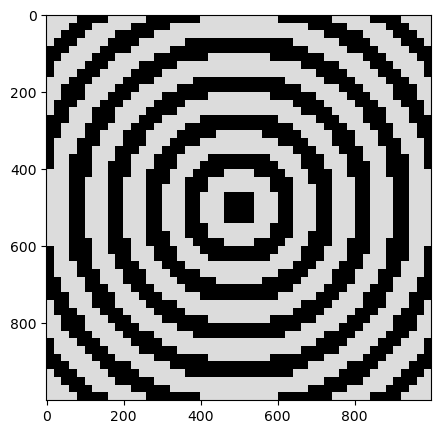


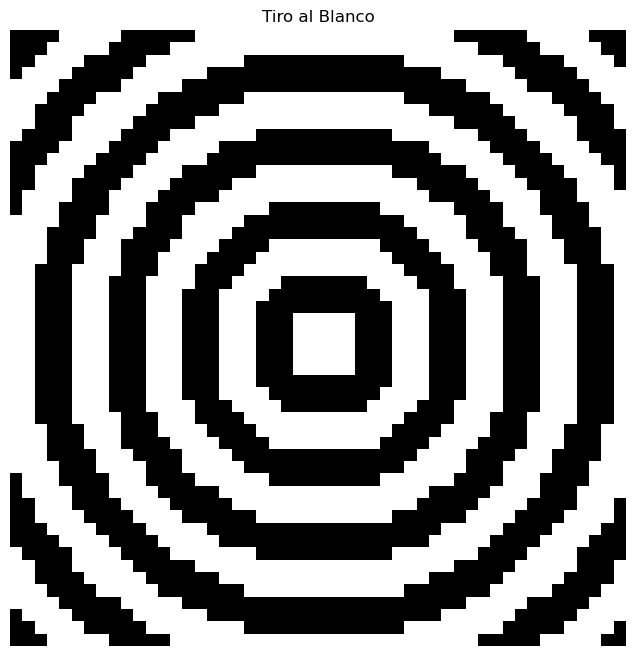

In [5]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

size = 50 
imagen_small = np.zeros((size, size), dtype=np.uint8)
cx, cy = size // 2, size // 2
ancho_anillo = max(1, size // 16)

for i in range(size):
    for j in range(size):
        distancia = np.sqrt((i - cy) ** 2 + (j - cx) ** 2)
        anillo = int(distancia / ancho_anillo)
        imagen_small[i, j] = 255 if anillo % 2 == 0 else 0


plt.figure(figsize=(8, 8))
plt.imshow(imagen_small, cmap='gray')
plt.title('Tiro al Blanco')
plt.axis('off')
plt.show()

# Ejercicio 2.
Genera la imagen tal cual se muestra acontinuación, tomar en cuenta el tamaño 
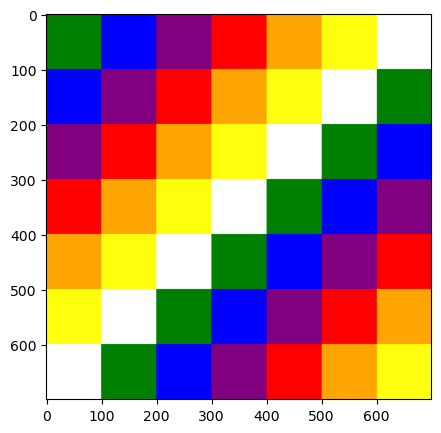

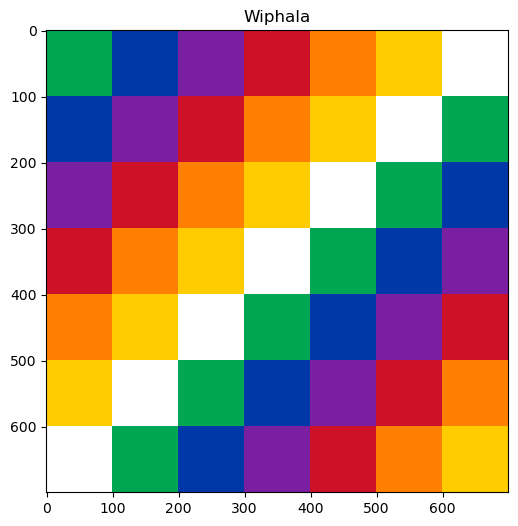

In [56]:
import matplotlib.pyplot as plt
import numpy as np

size_imagen = 700
rows = cols = 7
cell_height = size_imagen // rows
cell_width = size_imagen // cols

imagen = np.zeros((size_imagen, size_imagen, 3), dtype=np.uint8)


colores = [
    [  0, 166,  81],  # verde
    [  0,  56, 168],  # azul
    [123,  31, 162],  # violeta
    [206,  17,  38],  # rojo
    [255, 128,   0],  # naranja
    [255, 204,   0],  # amarillo
    [255, 255, 255],  # blanco
    
]

for i in range(rows):
    for j in range(cols):
        y_start = i * cell_height
        x_start = j * cell_width
        y_end = (i + 1) * cell_height if i < rows - 1 else size_imagen
        x_end = (j + 1) * cell_width if j < cols - 1 else size_imagen

        idx = (i + j) % len(colores)  
        imagen[y_start:y_end, x_start:x_end] = colores[idx]

plt.figure(figsize=(6,6))
plt.imshow(imagen, interpolation='nearest')
plt.title('Wiphala')
plt.show()

# Ejercicio 3.
Tomando en cuenta la imagen1.jpg elige un punto de interés al azar (funcion randomica), solariza y posteriza la imagen, realiza un tratamiento de umbralización(el de preferencia), mezcla tecnicas y obtiene un filtro artistico,lista todas las imágenes con sus correspondientes titulos, guarda todas las imágenes resultantes con sus nombres.

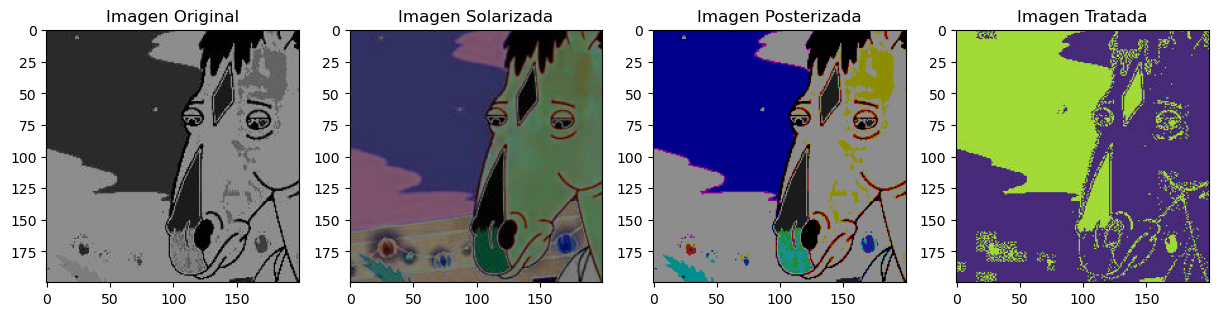

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread('imagen1.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#recortar de forma randomica
height, width, _ = img_rgb.shape
crop_size = 200
x_start = np.random.randint(0, width - crop_size)
y_start = np.random.randint(0, height - crop_size)
recorte_img = img_rgb[y_start:y_start + crop_size, x_start:x_start + crop_size]
plt.imsave('recorte.jpg', recorte_img)

#funcion posterizar
def posterizar(imagen,niveles):
    factor_escala = 255/niveles
    img_pos = np.round(imagen/factor_escala)*factor_escala
    return img_pos.astype(np.uint8)

#funcion solarizar
def solarizar(imagen, umbral):
    img_sol = np.where(imagen<umbral,imagen,255-imagen )
    return img_sol

imagen = cv2.imread('recorte.jpg')
umbral = 127
img_fin = solarizar(imagen,umbral)
plt.imsave('solarizada.jpg', img_fin)

nvl = 1.8
img_fin2 = posterizar(imagen,nvl)
plt.imsave('posterizada.jpg', img_fin2)

#Umbralizada OTSU
imagen=cv2.imread('posterizada.jpg',0)
_,otsu=cv2.threshold(imagen,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
imagen_fin=np.where(imagen>otsu,255,0).astype(np.uint8)
plt.imsave('umbralizada1.jpg', imagen_fin)

#Umbralizado adaptativo
image2=cv2.imread('umbralizada1.jpg',0)
ventana=75
k=2
imagen_fin2=cv2.adaptiveThreshold(image2,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY,ventana,k)
plt.imsave('umbralizada2.jpg', imagen_fin2)

#Falso color funcion
def falso_color(img_gray):
    escal_img = cv2.normalize(img_gray, None, 0, 255, cv2.NORM_MINMAX)
    falso_img = cv2.applyColorMap(escal_img, cv2.COLORMAP_JET)
    return falso_img

img_tratada = cv2.imread('umbralizada2.jpg',0)
img_falso_color = falso_color(img_tratada)
plt.imsave('falso_color.jpg', img_falso_color)


plt.figure(figsize=(15,5))
plt.subplot(1,4,1)
plt.title('Imagen Original')
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.subplot(1,4,2)
plt.title('Imagen Solarizada')
plt.imshow(cv2.cvtColor(img_fin, cv2.COLOR_BGR2RGB))
plt.subplot(1,4,3)
plt.title('Imagen Posterizada')
plt.imshow(cv2.cvtColor(img_fin2, cv2.COLOR_BGR2RGB))
plt.subplot(1,4,4)
plt.title('Imagen Tratada')
plt.imshow(img_tratada)
plt.show()

# Ejercicio 4.
Genera un avatar, basandote en una imagen tuya que usaste en practicas anteriores, este avatar debe tener filtros y/o umbralizaciones.
Guarda la imagen 

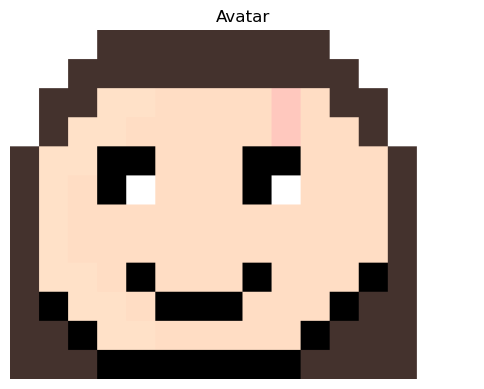

In [61]:
import numpy as np
import matplotlib.pyplot as plt

palette = {
    0: (255,255,255),   # fondo
    1: (0,0,0),         # borde
    2: (255, 221, 196),     # base
    3: (255, 225, 200),     # sombra
    4: (255,200,190),   # brillo
    5: (255, 255, 255),     # Blanco
    6: (68,50,45)
}

mapa = np.array([


[0,0,0,6,6,6,6,6,6,6,6,0,0,0,0,0],
[0,0,6,6,6,6,6,6,6,6,6,6,0,0,0,0],
[0,6,6,3,3,2,2,2,2,4,2,6,6,0,0,0],
[0,6,3,3,2,2,2,2,2,4,2,2,6,0,0,0],
[6,3,3,1,1,2,2,2,1,1,2,2,2,6,0,0],
[6,3,2,1,5,2,2,2,1,5,2,2,2,6,0,0],
[6,3,2,2,2,2,2,2,2,2,2,2,2,6,0,0],
[6,3,2,2,2,2,2,2,2,2,2,2,2,6,0,0],
[6,3,3,2,1,2,2,2,1,2,2,2,1,6,0,0],
[6,1,3,3,2,1,1,1,2,2,2,1,6,6,0,0],
[6,6,1,3,3,2,2,2,2,2,1,6,6,6,0,0],
[6,6,6,1,1,1,1,1,1,1,6,6,6,6,0,0],

], dtype=np.uint8)

h, w = mapa.shape
img = np.zeros((h, w, 3), dtype=np.uint8)

for k, col in palette.items():
    img[mapa == k] = col

scale = 40
img_big = img.repeat(scale, axis=0).repeat(scale, axis=1)

plt.figure(figsize=(6,6))
plt.imshow(img_big)
plt.axis('off')
plt.title("Avatar")
plt.show()